<a href="https://colab.research.google.com/github/UMA-GitHub-alt/lab_assignments/blob/main/%E7%A0%94%E7%A9%B6%E5%AE%A4%E8%AA%B2%E9%A1%8C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Colabのセルで実行して解凍します（! を忘れずに）
!tar -xzf /content/drive/MyDrive/labassignment2/train.tar.gz -C /content/
!tar -xzf /content/drive/MyDrive/labassignment2/val.tar.gz -C /content/
!tar -xzf /content/drive/MyDrive/labassignment2/test.tar.gz -C /content/

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
from tqdm import tqdm

# 1. データの前処理と読み込み (VGG16は224x224の入力が基本)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('/content/train', transform=transform)
val_dataset = datasets.ImageFolder('/content/val', transform=transform)
test_dataset = datasets.ImageFolder('/content/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. モデルの定義 (VGG-16)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用デバイス: {device}") # GPUが使われているか確認

model = models.vgg16(pretrained=False)

# 最後の出力層を2クラス（腫瘍なし:0, 腫瘍あり:1）に変更
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 2)
model = model.to(device)

# 3. 損失関数と最適化手法
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 4. 学習ループ (進捗バーとValidationを追加)
num_epochs = 5
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 15)

    # 学習フェーズ
    model.train()
    train_loss = 0.0
    train_corrects = 0

    # tqdmでtrain_loaderをラップして進捗バーを表示
    train_bar = tqdm(train_loader, desc="Training")
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # 損失と正解数を蓄積
        train_loss += loss.item() * inputs.size(0)
        train_corrects += torch.sum(preds == labels.data)

        # プログレスバーの右端に現在のバッチのLossをリアルタイム表示
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # 1エポック分の平均LossとAccuracyを計算
    epoch_train_loss = train_loss / len(train_dataset)
    epoch_train_acc = train_corrects.double() / len(train_dataset)

    # 検証フェーズ
    model.eval()
    val_loss = 0.0
    val_corrects = 0

    val_bar = tqdm(val_loader, desc="Validation")
    with torch.no_grad(): # 検証時は勾配計算を無効化（メモリ節約と高速化）
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    # 1エポック終了ごとの結果を出力
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")

# 5. テストデータでの評価
print("\n=== テストデータ評価 ===")
model.eval()
all_preds = []
all_labels = []

# テストデータにもプログレスバーを適用
test_bar = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for inputs, labels in test_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 精度と混同行列の算出
accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(cm)

使用デバイス: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Epoch 1/5
---------------


Validation: 100%|██████████| 46/46 [00:05<00:00,  8.71it/s]


Train Loss: 0.3694 | Train Acc: 0.8291
Val Loss:   0.3879 | Val Acc:   0.8715

Epoch 2/5
---------------


...

Train Loss: 0.1138 | Train Acc: 0.9704
Val Loss:   0.3079 | Val Acc:   0.8702

Epoch 5/5
---------------


Validation: 100%|██████████| 46/46 [00:05<00:00,  8.70it/s]


Train Loss: 0.1022 | Train Acc: 0.9716
Val Loss:   0.4056 | Val Acc:   0.8681

=== テストデータ評価 ===


Testing: 100%|██████████| 77/77 [00:08<00:00,  8.59it/s]


Test Accuracy: 94.91%
Confusion Matrix:
[[1117   78]
 [  47 1216]]


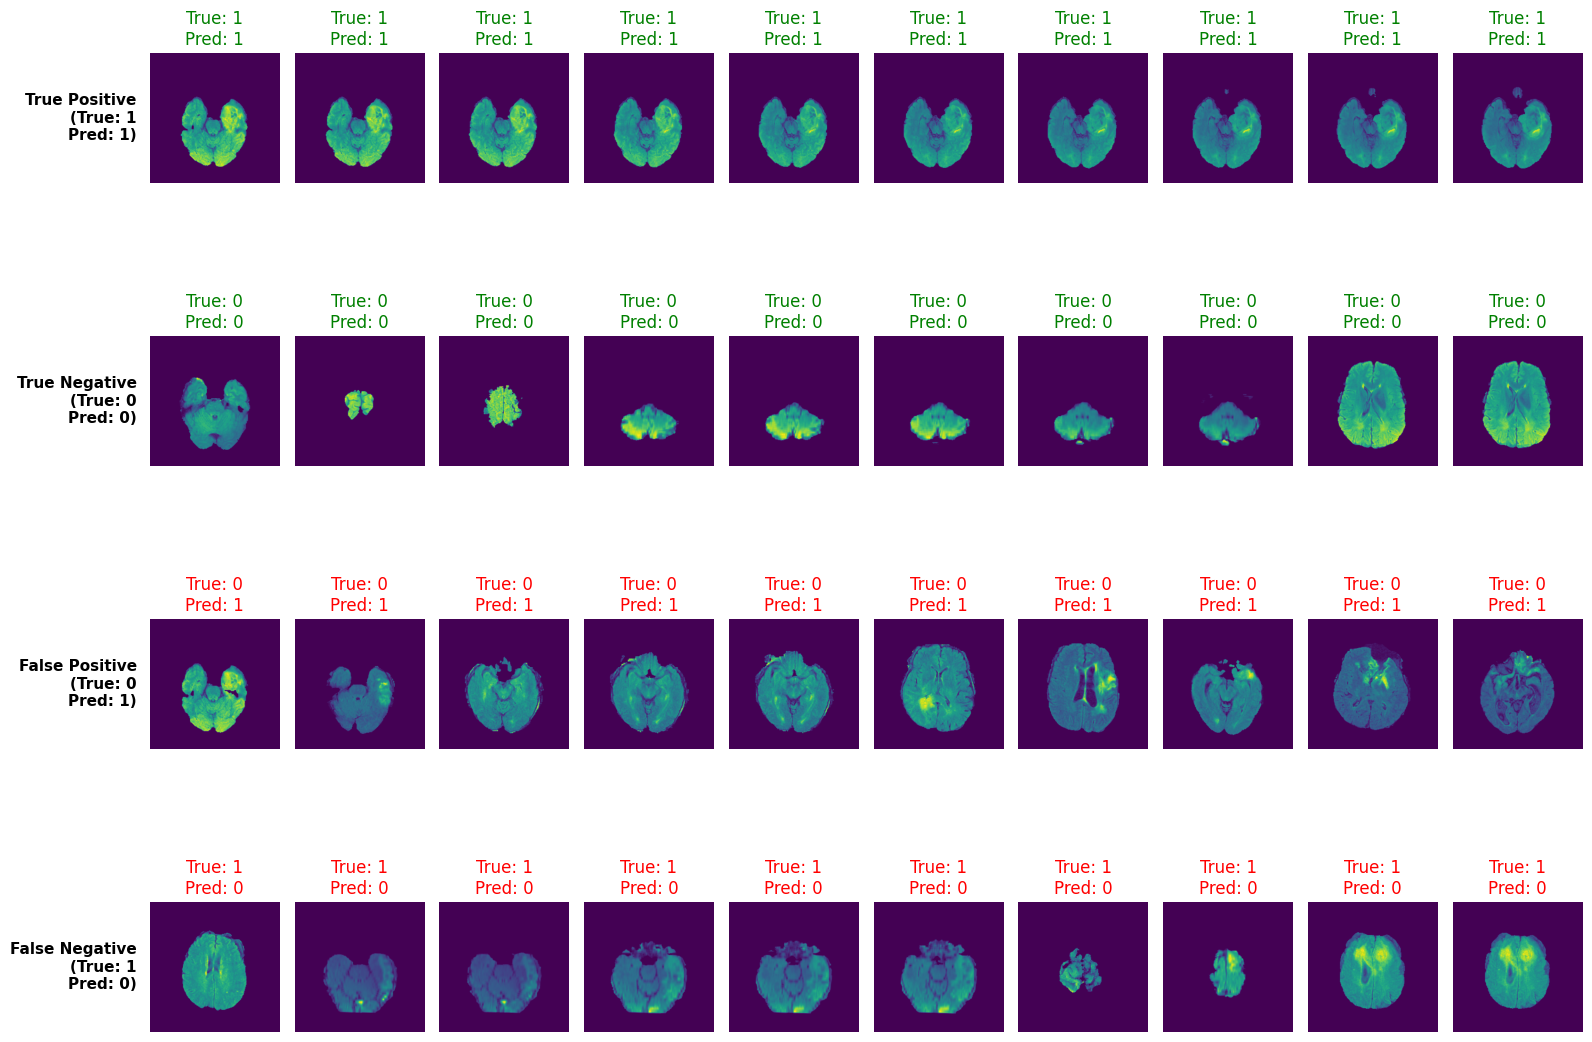

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# クラス名を取得 ('0_normal', '1_tumor' などのフォルダ名が自動で入っています)
class_names = test_dataset.classes

# クラスのインデックスを指定 (フォルダの並び順によって変わる場合は適宜変更してください)
NEG_CLASS = 0 # 腫瘍なし
POS_CLASS = 1 # 腫瘍あり

# shuffle=False なので、test_dataset.samples (パスとラベルのタプル) と
# all_preds (予測結果) の順番は完全に一致しています。これらを結合します。
all_cases = []
for (img_path, true_label), pred_label in zip(test_dataset.samples, all_preds):
    all_cases.append({
        'path': img_path,
        'true': true_label,
        'pred': pred_label
    })

# データを混同行列の4カテゴリに分類
tp_cases = [info for info in all_cases if info['true'] == POS_CLASS and info['pred'] == POS_CLASS] # 正解:あり / 予測:あり
tn_cases = [info for info in all_cases if info['true'] == NEG_CLASS and info['pred'] == NEG_CLASS] # 正解:なし / 予測:なし
fp_cases = [info for info in all_cases if info['true'] == NEG_CLASS and info['pred'] == POS_CLASS] # 正解:なし / 予測:あり (過検出)
fn_cases = [info for info in all_cases if info['true'] == POS_CLASS and info['pred'] == NEG_CLASS] # 正解:あり / 予測:なし (見逃し)

# Google Colabなど日本語フォントがない環境での文字化けを防ぐため、ラベルは英語ベースにしています
categories = {
    f"True Positive\n(True: {class_names[POS_CLASS]}\nPred: {class_names[POS_CLASS]})": tp_cases,
    f"True Negative\n(True: {class_names[NEG_CLASS]}\nPred: {class_names[NEG_CLASS]})": tn_cases,
    f"False Positive\n(True: {class_names[NEG_CLASS]}\nPred: {class_names[POS_CLASS]})": fp_cases,
    f"False Negative\n(True: {class_names[POS_CLASS]}\nPred: {class_names[NEG_CLASS]})": fn_cases
}

# プロットする設定（4行 × 最大5列）
num_images_per_row = 10
fig, axes = plt.subplots(4, num_images_per_row, figsize=(16, 12))

for row_idx, (cat_name, cases) in enumerate(categories.items()):
    for col_idx in range(num_images_per_row):
        ax = axes[row_idx, col_idx]

        # データが存在する列のみ画像をプロット（例：FNが2枚しかない場合は2枚だけ表示）
        if col_idx < len(cases):
            info = cases[col_idx]
            img = Image.open(info['path'])
            true_class = class_names[info['true']]
            pred_class = class_names[info['pred']]

            ax.imshow(img)

            # 正解（TP, TN）なら緑、不正解（FP, FN）なら赤でテキストを表示
            color = "green" if info['true'] == info['pred'] else "red"
            ax.set_title(f"True: {true_class}\nPred: {pred_class}", color=color)

        # 枠線と軸を非表示
        ax.axis('off')

    # 行の左側にカテゴリ名（TP, TNなど）を表示
    axes[row_idx, 0].text(-0.1, 0.5, cat_name, transform=axes[row_idx, 0].transAxes,
                          fontsize=11, va='center', ha='right', weight='bold')

# レイアウトを調整して表示
plt.tight_layout()
plt.show()